In [2]:
%load_ext autoreload
%autoreload 2

import os
ROOT_DIR = os.getcwd()[:os.getcwd().rfind('HEOM')]+ 'HEOM'
os.chdir(ROOT_DIR)

from heom import *
plt.style.use('heom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

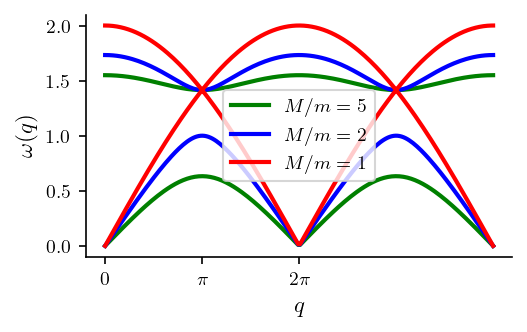

In [73]:
D = 1
q_list = np.linspace(0, 4*np.pi, 200)
fig, ax =plt.subplots()

m, M = 1, 5
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) + np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='g', label=r'$M/m=5$' )
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) - np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='g' )
m, M = 1, 2
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) + np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='b', label=r'$M/m=2$' )
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) - np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='b' )
m, M = 1, 1
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) + np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='r', label=r'$M/m=1$' )
ax.plot( q_list, np.sqrt( D/(m*M) * ((m+M) - np.sqrt((m+M)**2 - 4* m*M* np.sin(q_list/2)**2 ) ) ), color='r' )

ax.set_xticks([0,np.pi, 2*np.pi], ['0', r'$\pi$', r'$2\pi$'])
ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$\omega(q)$')
ax.legend()
fig.savefig('TheoMech_Blatt12.pdf')

In [17]:
def save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=False, useRFPlus=False):
    # output parameters for simulation
    params = {}
    params['idlingTime'] = idlingTime
    params['gateList'] = gateList
    params['bath'] = bath
    params['dtFB'] = dtFB
    params['stride'] = stride
    params['depth'] = depth
    params['bondDim'] = bondDim
    params['isRK13'] = isRK13
    params['useRFPlus'] = useRFPlus
    
    rhoIni = rho.pop('rhoIni')
    rho['rhoReal'] = rhoIni.real.tolist()
    rho['rhoImag'] = rhoIni.imag.tolist()
    params['rho'] = rho
    
    VTmp = {}
    VTmp['real'] = V.real.tolist()
    VTmp['imag'] = V.imag.tolist()
    params['VTmp'] = VTmp
    
    qc.metadata = params
    filePath = os.path.join(directory, 'qcData' + '_' + fileName)
    
    with open(filePath, 'wb') as file:
        qpy.dump(qc, file)

def run(directory, fileName):

    inputName = os.path.join(directory, 'qcData' + '_' + fileName)
    outputName = os.path.join(directory, fileName + '.csv')
    
    with open(inputName, 'rb') as file:
        qc = qpy.load(file)[0]

    params = qc.metadata
    idlingTime = params['idlingTime']
    gateList = params['gateList']
    rho = params['rho']
    rho['rhoIni'] = np.array(rho['rhoReal']) + 1j * np.array(rho['rhoImag'])
    bath = params['bath']
    VTmp = params['VTmp']
    V = np.array(VTmp['real']) + 1j * np.array(VTmp['imag'])
    dtFB = params['dtFB']
    stride = params['stride']
    depth = params['depth']
    bondDim = params['bondDim']
    isRK13 = params['isRK13']
    useRFPlus = params['useRFPlus']
    
    main(outputName, qc, idlingTime, gateList, rho,
         bath, V, dtFB, stride, depth, bondDim, isRK13, useRFPlus)

def plot_fidelity(ax, directory, fileName, hpc=False):

    if hpc: 
        inputName = os.path.join(directory, 'qc' + fileName)
    else: 
        inputName = os.path.join(directory, 'qcData' + '_' + fileName)
    outputName = os.path.join(directory, fileName + '.csv')

    t_list, dm_list = load_density_matrices(outputName)
    
    with open(inputName, 'rb') as file:
        qc = qpy.load(file)[0]
    params = qc.metadata
    
    U = Operator(qc).data
    rho = params['rho']
    
    rhoIni = np.array(rho['rhoReal']) + 1j * np.array(rho['rhoImag'])
    target = U @ rhoIni @ U.conj().T
    fids = [np.real(np.trace(rho @ target)) for rho in dm_list]

    ax.plot(t_list/(2*np.pi), fids)
    ax.set_xlabel(r"$\omega t/2\pi$")
    ax.set_ylabel("Fidelity")
    ax.set_ylim(0, 1.05)
    return ax

## One qubit unrealistic 

### Example 1

In [18]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus=False

directory = 'development/results/local'
fileName = 'rdo_1qubit'
save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))


65.89952635765076


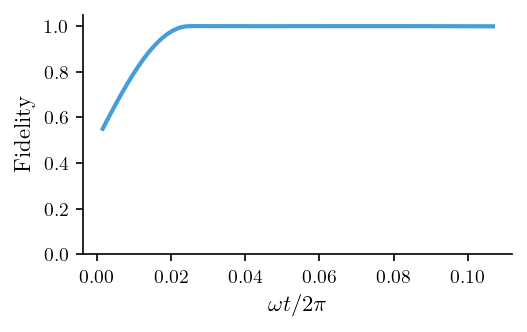

In [43]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

### Example 2

In [26]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus= True

save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))


41.59728240966797


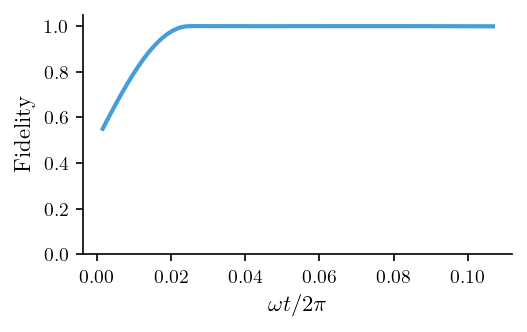

In [44]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

### Example 3

In [32]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1/2
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus= False

directory = 'development/results/local'
fileName = 'rdo_1qubit'
save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


190.07533764839172


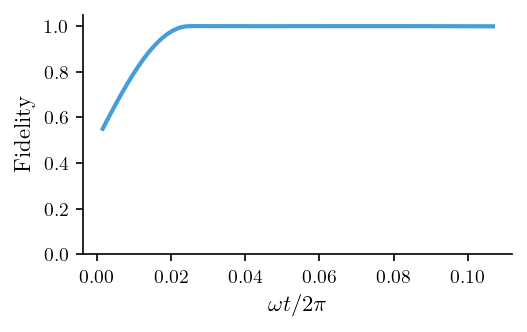

In [45]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

### Example 4

In [28]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1/2
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus= True

directory = 'development/results/local'
fileName = 'rdo_1qubit'
save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


135.6678328514099


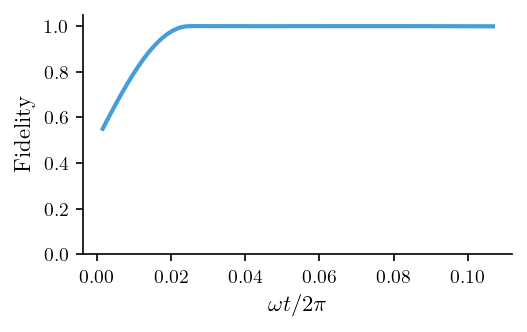

In [46]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

### Example 5

In [34]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1/2
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus= False

directory = 'development/results/local'
fileName = 'rdo_1qubit'
save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


190.1204915046692


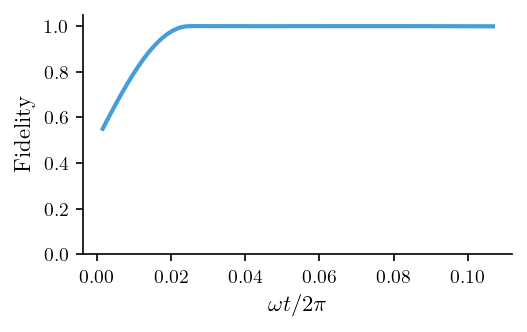

In [47]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

### Example 6

In [30]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1/8
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus= True

directory = 'development/results/local'
fileName = 'rdo_1qubit'
save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
run(directory, fileName)

print(time.time() - t0)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


93.21196436882019


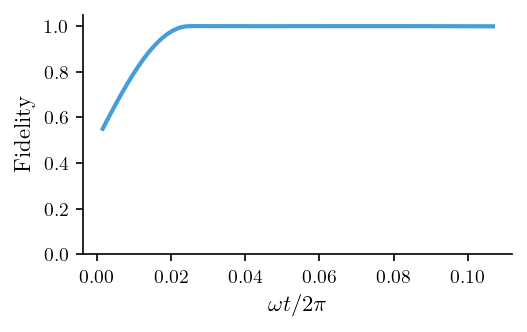

In [48]:
directory = 'development/results/local'
fileName = 'rdo_1qubit'
plot_fidelity(directory, fileName)

## One qubit realistic 

### slurm-19421492

In [31]:
# one qubit example realistic, s=1, time: 02:30:04
directory = 'development/results/hpc'
fileName = '19421492'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 31.41592653589793,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

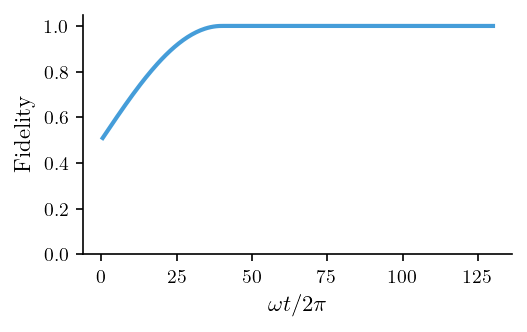

In [34]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19421497

In [37]:
# one qubit example realistic, s=1/2, time: 05:12:19
directory = 'development/results/hpc'
fileName = '19421497'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 31.41592653589793,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 0.5,
   'tol': 1e-06}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

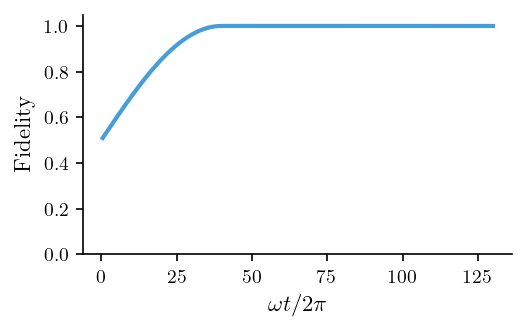

In [38]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19421501

In [39]:
# one qubit example realistic, s=1/8, time: 04:03:39
directory = 'development/results/hpc'
fileName = '19421501'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 31.41592653589793,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 0.125,
   'tol': 1e-06}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

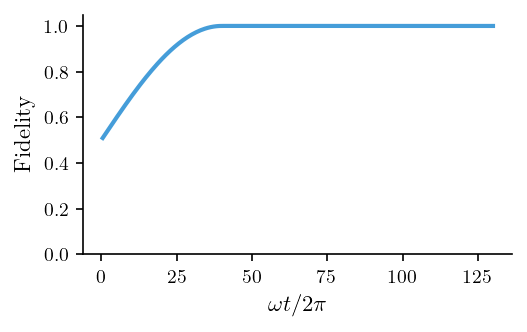

In [40]:
plot_fidelity(directory, fileName, hpc=True)

## Three qubit

### slurm-19404542

In [35]:
# 4 cores
directory = 'development/results/hpc'
fileName = '19404542'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]
   
params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 0.05}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 0.05}]],
 'bath': [{'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.001,
 'stride': 10,
 'depth': [2, 2, 2],
 'bondDim': 20,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0,

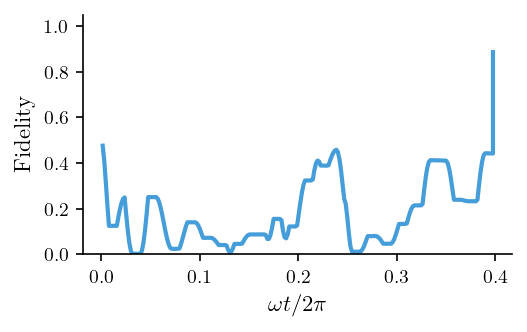

In [36]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19421507

In [41]:
# three qubit example realistic, s=1, time: 00:01:53
directory = 'development/results/hpc'
fileName = '19421507'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 1}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 1}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 1}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 1570.7963267948965}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 1570.7963267948965}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.002,
 'stride': 499,
 'depth': [1, 1, 1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   

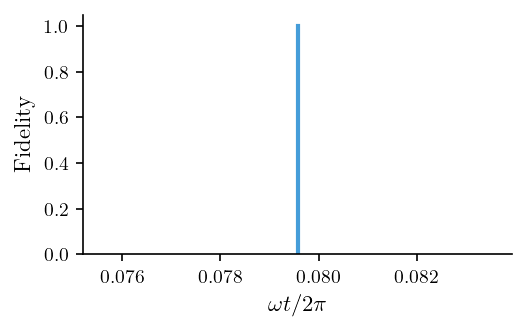

In [42]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19429777

In [49]:
# three qubit example realistic, s=1, 14:31:56
directory = 'development/results/hpc'
fileName = '19429777'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 1570.7963267948965}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 1570.7963267948965}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.002,
 'stride': 499,
 'depth': [1, 1, 1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],


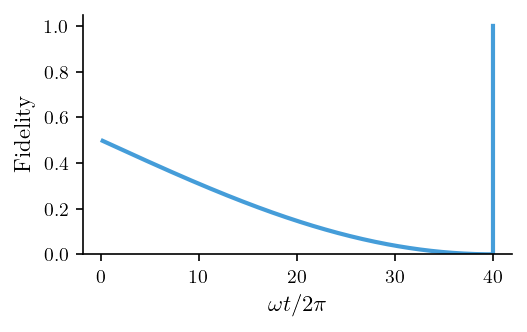

In [50]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19680590

In [3]:
# 12
directory = 'development/results/hpc'
fileName = '19680590'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 0.05}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 0.05}]],
 'bath': [{'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.001,
 'stride': 10,
 'depth': [2, 2, 2],
 'bondDim': 20,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0,

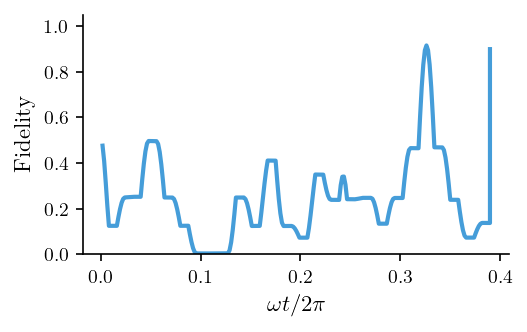

In [6]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19681237

In [9]:
# 1
directory = 'development/results/hpc'
fileName = '19681237'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 0.05}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 0.05}]],
 'bath': [{'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.001,
 'stride': 10,
 'depth': [2, 2, 2],
 'bondDim': 20,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0,

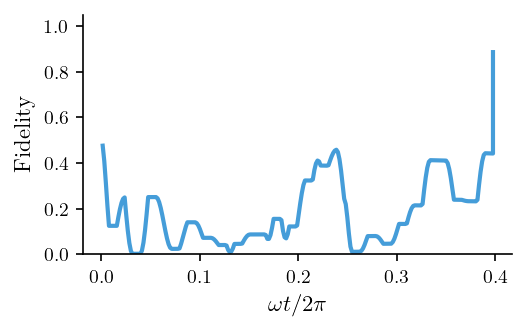

In [10]:
plot_fidelity(directory, fileName, hpc=True)

### slurm-19683987

In [25]:
# 16
directory = 'development/results/hpc'
fileName = '19683987'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[1], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[2], 'rxyStep', {'omega': -1.0, 'gateTime': 0.1}],
  [[0, 1], 'directCplStepVarJ', {'gateTime': 0.05}],
  [[1, 2], 'directCplStepVarJ', {'gateTime': 0.05}]],
 'bath': [{'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06},
  {'type': 'broadband',
   'beta': 5,
   'kappa': 0.0006366197723675814,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.001,
 'stride': 10,
 'depth': [2, 2, 2],
 'bondDim': 20,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 3,
  'omegaQ': [1.0, 1.0, 1.0],
  'rhoReal': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   [0.0, 0.0, 0.0, 0.0, 0.0,

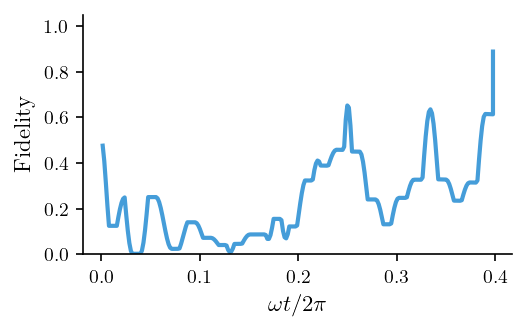

In [27]:
fig, ax = plt.subplots()
ax = plot_fidelity(ax, directory, fileName, hpc=True)

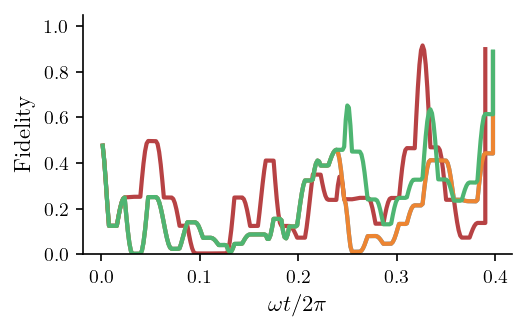

In [36]:
fig, ax = plt.subplots()

# 4
directory = 'development/results/hpc'
fileName = '19404542'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

# 12
directory = 'development/results/hpc'
fileName = '19680590'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

# 1   
directory = 'development/results/hpc'
fileName = '19681237'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

# 16
directory = 'development/results/hpc'
fileName = '19683987'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

### 16.1.

### slurm-19680596

In [18]:
# ohmic
directory = 'development/results/hpc'
fileName = '19680596'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

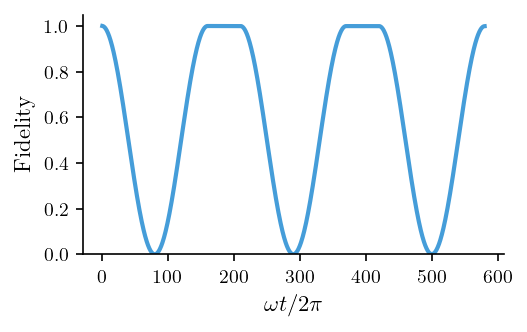

In [19]:
fig, ax = plt.subplots()
ax = plot_fidelity(ax, directory, fileName, hpc=True)

### slurm-19680597

In [20]:
# S=1/8, bondDim = 5
directory = 'development/results/hpc'
fileName = '19680597'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 0.125,
   'tol': 5e-07}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

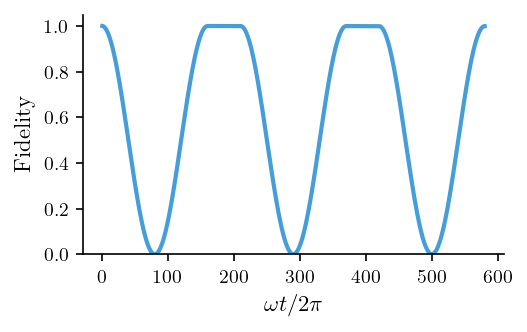

In [21]:
fig, ax = plt.subplots()
ax = plot_fidelity(ax, directory, fileName, hpc=True)

### slurm-19680607

In [37]:
# S=1/8, bondDim = 10
directory = 'development/results/hpc'
fileName = '19680607'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
params

{'idlingTime': 0,
 'gateList': [[[0],
   'rxyStep',
   {'omega': -1.0, 'gateTime': 502.6548245743669}]],
 'bath': [{'type': 'broadband',
   'beta': 8,
   'kappa': 1.5915494309189532e-07,
   'omegaC': 50,
   'exp': 1,
   'tol': 1e-06}],
 'dtFB': 0.005,
 'stride': 600,
 'depth': [1],
 'bondDim': 5,
 'isRK13': False,
 'useRFPlus': True,
 'rho': {'numQ': 1,
  'omegaQ': [1.0],
  'rhoReal': [[1.0, 0.0], [0.0, 0.0]],
  'rhoImag': [[0.0, 0.0], [0.0, 0.0]]},
 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]],
  'imag': [[[0.0, 0.0], [0.0, 0.0]]]}}

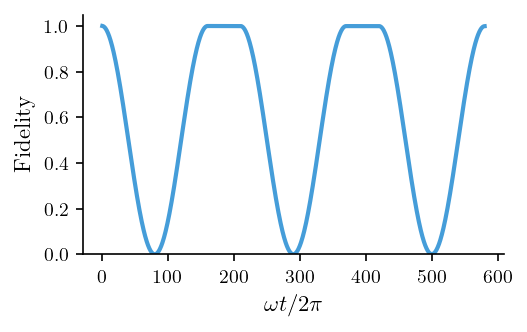

In [23]:
fig, ax = plt.subplots()
ax = plot_fidelity(ax, directory, fileName, hpc=True)

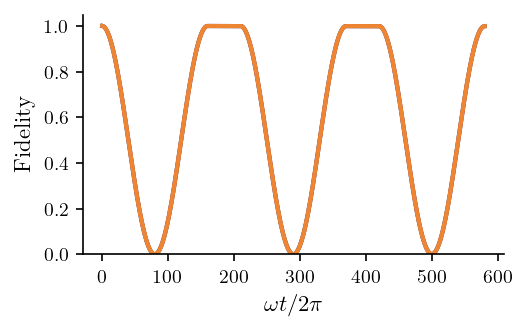

In [24]:
fig, ax = plt.subplots()

# ohmic
directory = 'development/results/hpc'
fileName = '19680596'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

# S=1/8, bondDim = 5
directory = 'development/results/hpc'
fileName = '19680597'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

# S=1/8, bondDim = 10
directory = 'development/results/hpc'
fileName = '19680607'

inputName = os.path.join(directory, 'qc' + fileName)
with open(inputName, 'rb') as file:
    qc = qpy.load(file)[0]

params = qc.metadata
ax = plot_fidelity(ax, directory, fileName, hpc=True)

## Combination with error mitigation

In [18]:
import time 
from tqdm import tqdm
t0 = time.time()

xm, xp = q.sigmax().eigenstates()[1]
xp, xm = xp * xp.dag(), xm * xm.dag()
ym, yp = q.sigmay().eigenstates()[1]
yp, ym = yp * yp.dag(), ym * ym.dag()
zp, zm = q.sigmaz().eigenstates()[1]
zm, zp = zp * zp.dag(), zm * zm.dag()

for label, rhoIni in tqdm(zip(['zp','zm','xp','yp'], [zp,zm,xp,yp])):
    
    qc = QuantumCircuit(1)
    qc.rx(0.5*np.pi, 0)
    qc.delay(0, 0)
    qc.ry(0.5*np.pi, 0)
    qc.delay(0, 0)
    qc.ry(-0.5*np.pi, 0)
    
    idlingTime = 0.1
    
    rho = {'numQ': 1}
    rho['rhoIni'] = rhoIni.full()
    rho['omegaQ'] = [1.]
    
    gateList = [[[0], 'rxyStep', ]]
    kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
    gateList = [[[0], 'rxyStep', kwargs1Q]]
    
    bath = [{'type': 'broadband'}]
    bath[0]['beta'] = 5
    bath[0]['kappa'] = 0.004 / 2 / np.pi
    bath[0]['omegaC'] = 50
    bath[0]['exp'] = 1/2
    bath[0]['tol'] = 1e-6
    
    V = np.array([
        [[0, 1],
         [1, 0]]
    ], dtype=np.complex128)
    
    dtFB = 0.001
    
    strideTime = 0.01
    
    stride = int(strideTime / dtFB)
    
    depth = [2]
    bondDim = 20
    
    isRK13 = False
    useRFPlus=False
    
    directory = 'development/results/error_mitigation'
    fileName = label
    save_params(directory, fileName, qc, idlingTime, gateList, rho, bath, V, dtFB, stride, depth, bondDim, isRK13=isRK13, useRFPlus=useRFPlus)
    run(directory, fileName)

print(time.time() - t0)

0it [00:00, ?it/s]C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol
4it [11:52, 178.13s/it]

712.5057256221771


In [6]:
from NVcenter.mitigation import *
directory = 'development/results/error_mitigation'

input_array = []
for fileName in ['zp','zm','xp','yp']:
    outputName = os.path.join(directory, fileName + '.csv')
    t_list, dm_list = load_density_matrices(outputName)
    input_array.append( [[q.expect(q.Qobj(rho), op) for rho in dm_list] for op in [q.sigmax(),q.sigmay(),q.sigmaz()]] )
input_array = np.array(input_array)
PTM_list = construct_PTM(input_array)

In [17]:
PTM = PTM_list[:,:,-1]    
inv_PTM = invert_PTM(PTM)
inv_choi = PTM_to_Choi(q.Qobj(inv_PTM))
p, choi_plus, choi_minus = get_CPTP_Choi(inv_choi)

left_side = inv_choi
right_side = (1 + p) * choi_plus - p * choi_minus
print(np.allclose(left_side.full(), right_side.full(), atol=1e-5))

kraus_sum is diagonal True
True


In [18]:
p

np.float64(0.003429450046758802)